In [31]:
# ============================================================
# 21. Logistic Regression (구조 검증)
# ============================================================
#
# 목적:
# 1. 환자 단위 split 유지
# 2. 로지스틱 회귀를 통한 위험 요인 방향성 확인
#
# 입력:
# - feature_table_logistic_base.csv
#
# 출력:
# - (중간 확인용) 모델 객체
#
# 주의:
# - 성능 최적화 목적 아님
# - 해석 가능성 중심
# ============================================================

In [32]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [33]:
INPUT_PATH = "/home/oracle/Coding/wsl_projects/miniprj/data-pipeline/data/processed/feature_table_logistic_base.csv"
LABEL_COL = "death_next_24h"

df = pd.read_csv(INPUT_PATH)

In [34]:
# 전처리 단계 수정
LABEL_COL = "death_next_24h"

# 미래 이벤트 컬럼 제거
future_cols = [c for c in df.columns if "_next_" in c]

X = df.drop(columns=["stay_id"]+future_cols)
y = df[LABEL_COL]

In [35]:
# 결측치 플래그 제거
missing_flag_cols = [
    c for c in X.columns
    if ("missing" in c.lower())
]

print("Removing missing flag cols:")
print(missing_flag_cols)

X = X.drop(columns=missing_flag_cols)

Removing missing flag cols:
['lactate_missing', 'gcs_missing_flag', 'urine_missing_flag']


In [36]:
# binary/continuous 정의
binary_cols = [
    c for c in X.columns
    if X[c].dropna().isin([0, 1]).all()
]

continuous_cols = [
    c for c in X.columns
    if c not in binary_cols
]

print(f"binary cols: {len(binary_cols)}")
print(f"continuous cols: {len(continuous_cols)}")


binary cols: 2
continuous cols: 61


In [37]:
# GroupShuffleSplit 사용
from sklearn.model_selection import GroupShuffleSplit

groups = df["stay_id"]

gss = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]


In [38]:
# 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)
X_test_scaled[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

In [39]:
# 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

logit.fit(X_train_scaled, y_train)
print("Logistic fitted (no missing flags).")

Logistic fitted (no missing flags).


In [40]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_test_proba = logit.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")
print(f"PR-AUC baseline: {y_test.mean():.4f}")

ROC-AUC: 0.9091
PR-AUC : 0.1989
PR-AUC baseline: 0.0081


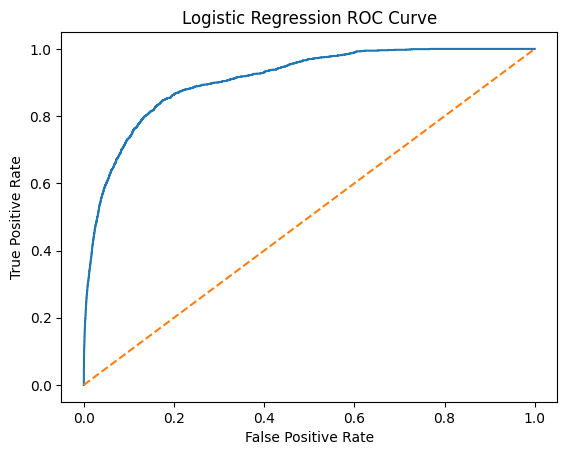

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.show()


In [42]:
## 뭔가 이상하다ㅏ..?
# 체크 1. 입력 X 컬럼에 미래 정보를 포함하는 label이 남아 있는지
[c for c in X_train_scaled.columns if "next_" in c]

[]

In [43]:
EXCLUDE_COLS = []

In [44]:
# 모든 미래 정보 제거
future_cols = [c for c in df.columns if "_next_" in c]

print("Dropping future cols:", future_cols)

X = df.drop(columns=EXCLUDE_COLS + future_cols)
y = df[LABEL_COL]


Dropping future cols: ['vent_next_6h', 'composite_next_6h', 'vent_next_12h', 'pressor_next_12h', 'composite_next_12h', 'vent_next_24h', 'pressor_next_24h', 'composite_next_24h', 'death_next_24h']


In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [46]:
y_train.mean(), y_test.mean()

(0.009483133342106627, 0.008104086865681091)

In [47]:
X = df.drop(columns=[LABEL_COL, "stay_id"])
y = df[LABEL_COL]
groups = df["stay_id"]


In [48]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

In [49]:
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [50]:
# 스케일 (정규화)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [51]:
logit = LogisticRegression(solver="lbfgs", max_iter=1000)
logit.fit(X_train_scaled, y_train)
print("Logistic fitted.")

Logistic fitted.


In [52]:
# 양성 클래스(사망=1) 확률
y_train_proba = logit.predict_proba(X_train_scaled)[:, 1]
y_test_proba  = logit.predict_proba(X_test_scaled)[:, 1]


In [53]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test, y_test_proba)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {test_auc:.4f}")


Train ROC-AUC: 0.9988
Test  ROC-AUC: 0.9993
